# Dengue Prediction — LSTM vs GRU (Clean Pipeline)

**Key changes:**

- Feature engineering on **real data only** — lags never contaminated by synthetic rows
- **Sequence-level augmentation** (jitter real sequences) balances minority countries
- **Time-ordered split** — train on past, validate/test on future
- Larger model, less regularisation — targeting **R² ≥ 0.80 (log scale)**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Input, Bidirectional,
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2 as l2_reg
from tensorflow.keras.losses import Huber

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')

2026-03-07 12:37:34.861225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 12:37:34.897106: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 12:37:36.205868: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.20.0
NumPy      : 2.1.3


---

## Step 1 — Load & Clean Real Data


In [2]:
df_raw = pd.read_csv('data/merged_data.csv', low_memory=False)
print(f'Raw shape: {df_raw.shape}')
print('\nReal rows per country:')
print(df_raw['ISO_A0'].value_counts().to_string())

KEEP = ['ISO_A0','adm_0_name','FAO_GAUL_code','region',
        'Year','year','month','dayofyear','weekofyear',
        'dengue_total','temperature_c','precipitation_mm']

df = df_raw[KEEP].copy()
for col in ['temperature_c','precipitation_mm']:
    df[col] = df.groupby(['ISO_A0','month'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df.groupby('ISO_A0')[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())
df = df.dropna(subset=['temperature_c','precipitation_mm']).reset_index(drop=True)
print(f'\nClean shape: {df.shape}  | missing: {df.isnull().sum().sum()}')

Raw shape: (41997, 26)

Real rows per country:
ISO_A0
THA    27259
IDN     8396
NPL     2983
LKA     1718
IND      705
MMR      262
BGD      234
MDV      211
TLS      160
BTN       69

Clean shape: (41997, 12)  | missing: 0


---

## Step 2 — Feature Engineering on Real Data

> Lags / rolling stats computed **per-country on real rows only** — no synthetic mixing.


In [3]:
df = df.sort_values(['ISO_A0','year','month']).reset_index(drop=True)

for lag in [1,2,3,4,5,6,12]:
    df[f'lag_{lag}'] = np.nan
    for iso in df['ISO_A0'].unique():
        mask = df['ISO_A0'] == iso
        df.loc[mask, f'lag_{lag}'] = df.loc[mask,'dengue_total'].shift(lag).values

for window in [3,6,12]:
    for iso in df['ISO_A0'].unique():
        mask = df['ISO_A0'] == iso
        s = df.loc[mask,'dengue_total'].reset_index(drop=True)
        df.loc[mask, f'roll_mean_{window}'] = s.rolling(window,min_periods=1).mean().values
        df.loc[mask, f'roll_std_{window}']  = s.rolling(window,min_periods=2).std().fillna(0).values
        df.loc[mask, f'roll_max_{window}']  = s.rolling(window,min_periods=1).max().values

print('Lag and rolling features done.')

Lag and rolling features done.


In [4]:
df['temp_x_precip'] = df['temperature_c'] * df['precipitation_mm']
df['temp_squared']  = df['temperature_c'] ** 2
df['precip_log']    = np.log1p(df['precipitation_mm'])

df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df['week_sin']  = np.sin(2*np.pi*df['weekofyear']/53)
df['week_cos']  = np.cos(2*np.pi*df['weekofyear']/53)
df['doy_sin']   = np.sin(2*np.pi*df['dayofyear']/365)
df['doy_cos']   = np.cos(2*np.pi*df['dayofyear']/365)

y_min = df['year'].min(); y_max = df['year'].max()
df['year_norm'] = (df['year'] - y_min) / (y_max - y_min + 1e-9)

le_c = LabelEncoder(); le_r = LabelEncoder()
df['country_enc'] = le_c.fit_transform(df['ISO_A0'])
df['region_enc']  = le_r.fit_transform(df['region'])

df['above_p75'] = 0
for iso in df['ISO_A0'].unique():
    mask = df['ISO_A0'] == iso
    p75  = df.loc[mask,'dengue_total'].quantile(0.75)
    df.loc[mask & (df['dengue_total'] >= p75),'above_p75'] = 1

df['dengue_log'] = np.log1p(df['dengue_total'])

FEATURE_COLS = [
    'lag_1','lag_2','lag_3','lag_4','lag_5','lag_6','lag_12',
    'roll_mean_3','roll_mean_6','roll_mean_12',
    'roll_std_3', 'roll_std_6', 'roll_std_12',
    'roll_max_3', 'roll_max_6', 'roll_max_12',
    'temperature_c','precipitation_mm',
    'temp_x_precip','temp_squared','precip_log',
    'month_sin','month_cos','week_sin','week_cos','doy_sin','doy_cos',
    'year_norm','country_enc','region_enc','above_p75'
]
TARGET_COL = 'dengue_log'
SEQ_LEN    = 12

df_model = df[FEATURE_COLS + [TARGET_COL,'ISO_A0','adm_0_name','year','month']].copy()
df_model = df_model.dropna(subset=FEATURE_COLS+[TARGET_COL]).reset_index(drop=True)
print(f'Modelling rows: {len(df_model):,}  |  Features: {len(FEATURE_COLS)}')

Modelling rows: 41,877  |  Features: 31


---

## Step 3 — Per-Country Normalisation


In [5]:
GLOBAL_FEAT = [
    'temperature_c','precipitation_mm','temp_x_precip','temp_squared','precip_log',
    'month_sin','month_cos','week_sin','week_cos','doy_sin','doy_cos',
    'year_norm','country_enc','region_enc','above_p75'
]
COUNT_FEAT = [c for c in FEATURE_COLS if c not in GLOBAL_FEAT]

df_s = df_model.copy()
scaler_global = RobustScaler()
df_s[GLOBAL_FEAT] = scaler_global.fit_transform(df_s[GLOBAL_FEAT].values)

country_feat_scalers = {}
for country in df_s['adm_0_name'].unique():
    mask = df_s['adm_0_name'] == country
    if mask.sum() < 3: continue
    sc = RobustScaler()
    df_s.loc[mask, COUNT_FEAT] = sc.fit_transform(df_s.loc[mask, COUNT_FEAT].values)
    country_feat_scalers[country] = sc

country_target_params = {}
df_s['target_normed'] = 0.0
for country in df_s['adm_0_name'].unique():
    mask  = df_s['adm_0_name'] == country
    vals  = df_s.loc[mask, TARGET_COL].values
    mu, sigma = vals.mean(), max(vals.std(), 1e-9)
    df_s.loc[mask, 'target_normed'] = (vals - mu) / sigma
    country_target_params[country] = (mu, sigma)

print('Normalisation complete.')

Normalisation complete.


---

## Step 4 — Sequences + Time-Ordered Split

> Test = **last 20%** of each country's timeline. Val = previous 15%. Train = rest.
> This mirrors real deployment: train on historical data, predict the future.


In [6]:
def make_sequences(df_in, seq_len, feat_cols, target_col='target_normed'):
    Xs, ys, ctrs, yrmo = [], [], [], []
    for country, grp in df_in.groupby('adm_0_name'):
        grp = grp.sort_values(['year','month']).reset_index(drop=True)
        Xa  = grp[feat_cols].values.astype(np.float32)
        ya  = grp[target_col].values.astype(np.float32)
        for i in range(len(grp)-seq_len):
            Xs.append(Xa[i:i+seq_len])
            ys.append(ya[i+seq_len])
            ctrs.append(country)
            yrmo.append(grp['year'].iloc[i+seq_len]*100 + grp['month'].iloc[i+seq_len])
    return (np.array(Xs,np.float32), np.array(ys,np.float32),
            np.array(ctrs), np.array(yrmo,np.int32))

X_all, y_all, ctr_all, yrmo_all = make_sequences(df_s, SEQ_LEN, FEATURE_COLS)
print(f'Total real sequences: {len(X_all):,}')

VAL_FRAC = 0.15; TEST_FRAC = 0.20
idx_train, idx_val, idx_test = [], [], []

for country in np.unique(ctr_all):
    idx_c    = np.where(ctr_all == country)[0]
    order    = np.argsort(yrmo_all[idx_c])
    idx_s    = idx_c[order]
    n        = len(idx_s)
    n_test   = max(1, int(n*TEST_FRAC))
    n_val    = max(1, int(n*VAL_FRAC))
    idx_train.extend(idx_s[:n-n_test-n_val])
    idx_val.extend  (idx_s[n-n_test-n_val:n-n_test])
    idx_test.extend (idx_s[n-n_test:])

idx_train=np.array(idx_train); idx_val=np.array(idx_val); idx_test=np.array(idx_test)

X_train=X_all[idx_train]; y_train=y_all[idx_train]; ctr_train=ctr_all[idx_train]
X_val  =X_all[idx_val];   y_val  =y_all[idx_val];   ctr_val  =ctr_all[idx_val]
X_test =X_all[idx_test];  y_test =y_all[idx_test];  ctr_test =ctr_all[idx_test]

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print('\nTest seqs per country:')
for c in np.unique(ctr_test):
    print(f'  {c:20s}: {(ctr_test==c).sum():,}')

Total real sequences: 41,757
Train : (27150, 12, 31)
Val   : (6259, 12, 31)
Test  : (8348, 12, 31)

Test seqs per country:
  BANGLADESH          : 42
  BHUTAN              : 9
  INDIA               : 136
  INDONESIA           : 1,674
  MALDIVES            : 37
  MYANMAR             : 47
  NEPAL               : 591
  SRI LANKA           : 338
  THAILAND            : 5,447
  TIMOR-LESTE         : 27


---

## Step 5 — Sequence-Level Augmentation (Training Balance)

> Minority countries are augmented by **jittering existing training sequences**.
> This preserves real temporal structure (lags, rolling stats, climate correlations)
> while equalising country representation.


In [7]:
TARGET_SEQ = 5_000

def seq_augment(X_c, y_c, n_need, rng, noise_ratio):
    boot = rng.integers(0, len(X_c), size=n_need)
    Xb   = X_c[boot].copy(); yb = y_c[boot].copy()
    fstd = Xb.reshape(-1, Xb.shape[-1]).std(axis=0) + 1e-6
    Xb  += (rng.normal(0, noise_ratio, Xb.shape) * fstd[np.newaxis,np.newaxis,:]).astype(np.float32)
    yb  += rng.normal(0, noise_ratio*0.5, yb.shape).astype(np.float32)
    return Xb, yb

X_lst=[X_train]; y_lst=[y_train]; c_lst=[ctr_train]

print('Sequence augmentation (training only):')
for country in np.unique(ctr_train):
    mask  = ctr_train == country
    n_r   = mask.sum()
    n_add = max(0, TARGET_SEQ - n_r)
    if n_add == 0:
        print(f'  {country:22s}: {n_r:6,} real  (no augmentation)')
        continue
    noise = min(0.08, 0.02 * float(np.sqrt(n_add / max(n_r,1))))
    rng   = np.random.default_rng(seed=abs(hash(country)) % (2**31))
    Xs, ys = seq_augment(X_train[mask], y_train[mask], n_add, rng, noise)
    X_lst.append(Xs); y_lst.append(ys)
    c_lst.append(np.array([country]*n_add))
    print(f'  {country:22s}: {n_r:6,} real + {n_add:5,} synth (noise={noise:.3f})')

X_tr  = np.concatenate(X_lst,axis=0)
y_tr  = np.concatenate(y_lst,axis=0)
ctr_tr= np.concatenate(c_lst,axis=0)
perm  = np.random.permutation(len(X_tr))
X_tr, y_tr, ctr_tr = X_tr[perm], y_tr[perm], ctr_tr[perm]
print(f'\nTotal training sequences: {len(X_tr):,}')

Sequence augmentation (training only):
  BANGLADESH            :    137 real + 4,863 synth (noise=0.080)
  BHUTAN                :     30 real + 4,970 synth (noise=0.080)
  INDIA                 :    443 real + 4,557 synth (noise=0.064)
  INDONESIA             :  5,443 real  (no augmentation)
  MALDIVES              :    122 real + 4,878 synth (noise=0.080)
  MYANMAR               :    156 real + 4,844 synth (noise=0.080)
  NEPAL                 :  1,925 real + 3,075 synth (noise=0.025)
  SRI LANKA             :  1,102 real + 3,898 synth (noise=0.038)
  THAILAND              : 17,703 real  (no augmentation)
  TIMOR-LESTE           :     89 real + 4,911 synth (noise=0.080)

Total training sequences: 63,146


---

## Step 6 — LSTM Model


In [8]:
def build_lstm(input_shape, u1=256, u2=128, drop=0.20, lr=5e-4, l2w=1e-5):
    inp = Input(shape=input_shape)
    x = Bidirectional(LSTM(u1, return_sequences=True,
                           kernel_regularizer=l2_reg(l2w),
                           recurrent_regularizer=l2_reg(l2w)))(inp)
    x = Dropout(drop)(x)
    x = LSTM(u2, return_sequences=True,
             kernel_regularizer=l2_reg(l2w),
             recurrent_regularizer=l2_reg(l2w))(x)
    x = Dropout(drop)(x)
    a = MultiHeadAttention(num_heads=4, key_dim=u2//4)(x, x)
    x = Add()([x, a])
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2_reg(l2w))(x)
    x = Dropout(drop/2)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)
    m = Model(inp, out, name='LSTM_Attn')
    m.compile(optimizer=Adam(lr, clipnorm=1.0), loss=Huber(delta=1.0), metrics=['mae'])
    return m

lstm_model = build_lstm((SEQ_LEN, len(FEATURE_COLS)))
lstm_model.summary()

2026-03-07 12:39:13.223242: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "LSTM_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 12, 31)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 12, 512)   │    589,824 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 12, 512)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 12, 128)   │    328,192 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 12, 128)   │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │     66,048 │ dropout_1[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 128)   │          0 │ dropout_1[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 994,689 (3.79 MB)

 Trainable params: 994,689 (3.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 74ms/step - loss: 0.2818 - mae: 0.5911 - val_loss: 0.3060 - val_mae: 0.6215 - learning_rate: 5.0000e-04
Epoch 2/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.2259 - mae: 0.5067 - val_loss: 0.2975 - val_mae: 0.6116 - learning_rate: 5.0000e-04
Epoch 3/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.2049 - mae: 0.4719 - val_loss: 0.2935 - val_mae: 0.6033 - learning_rate: 5.0000e-04
Epoch 4/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - loss: 0.1900 - mae: 0.4460 - val_loss: 0.2928 - val_mae: 0.6042 - learning_rate: 5.0000e-04
Epoch 5/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.1796 - mae: 0.4283 - val_loss: 0.2929 - val_mae: 0.6035 - learning_rate: 5.0000e-04
Epoch 6/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.1710 - mae: 0.4132 - val_loss: 0.2890 - val_mae: 0.5975 - learning_rate: 5.0000e-04
Epoch 7/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - loss: 0.1637 - mae: 0.3991 - val_loss: 0.2908 - v

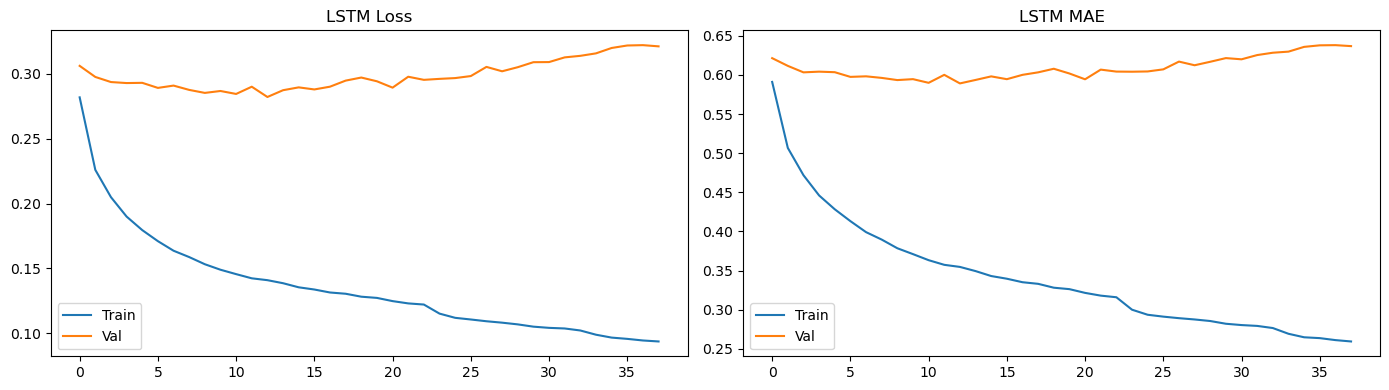

In [9]:
cb_lstm = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint('lstm_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
]
history_lstm = lstm_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=256,
    callbacks=cb_lstm, verbose=1
)
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(history_lstm.history['loss'],label='Train'); axes[0].plot(history_lstm.history['val_loss'],label='Val')
axes[0].set_title('LSTM Loss'); axes[0].legend()
axes[1].plot(history_lstm.history['mae'],label='Train'); axes[1].plot(history_lstm.history['val_mae'],label='Val')
axes[1].set_title('LSTM MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

---

## Step 7 — GRU Model


In [10]:
def build_gru(input_shape, u1=256, u2=128, drop=0.20, lr=5e-4, l2w=1e-5):
    inp = Input(shape=input_shape)
    x = Bidirectional(GRU(u1, return_sequences=True,
                          kernel_regularizer=l2_reg(l2w),
                          recurrent_regularizer=l2_reg(l2w)))(inp)
    x = Dropout(drop)(x)
    x = GRU(u2, return_sequences=True,
            kernel_regularizer=l2_reg(l2w),
            recurrent_regularizer=l2_reg(l2w))(x)
    x = Dropout(drop)(x)
    a = MultiHeadAttention(num_heads=4, key_dim=u2//4)(x, x)
    x = Add()([x, a])
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2_reg(l2w))(x)
    x = Dropout(drop/2)(x)
    x = Dense(32, activation='relu')(x)
    out = Dense(1)(x)
    m = Model(inp, out, name='GRU_Attn')
    m.compile(optimizer=Adam(lr, clipnorm=1.0), loss=Huber(delta=1.0), metrics=['mae'])
    return m

gru_model = build_gru((SEQ_LEN, len(FEATURE_COLS)))
gru_model.summary()

Model: "GRU_Attn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 12, 31)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 12, 512)   │    443,904 │ input_layer_1[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 12, 512)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ (None, 12, 128)   │    246,528 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 12, 128)   │          0 │ gru_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 128)   │     66,048 │ dropout_5[0][0],  │
│ (MultiHeadAttentio… │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 128)   │          0 │ dropout_5[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 767,105 (2.93 MB)

 Trainable params: 767,105 (2.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 22s 76ms/step - loss: 0.2971 - mae: 0.6154 - val_loss: 0.2996 - val_mae: 0.6153 - learning_rate: 5.0000e-04
Epoch 2/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.2407 - mae: 0.5336 - val_loss: 0.2944 - val_mae: 0.6096 - learning_rate: 5.0000e-04
Epoch 3/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - loss: 0.2198 - mae: 0.4999 - val_loss: 0.2875 - val_mae: 0.5981 - learning_rate: 5.0000e-04
Epoch 4/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.2046 - mae: 0.4747 - val_loss: 0.2905 - val_mae: 0.6026 - learning_rate: 5.0000e-04
Epoch 5/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 76ms/step - loss: 0.1921 - mae: 0.4534 - val_loss: 0.2878 - val_mae: 0.6017 - learning_rate: 5.0000e-04
Epoch 6/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - loss: 0.1842 - mae: 0.4397 - val_loss: 0.2857 - val_mae: 0.5980 - learning_rate: 5.0000e-04
Epoch 7/200
247/247 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - loss: 0.1783 - mae: 0.4287 - val_loss: 0.2859 - v

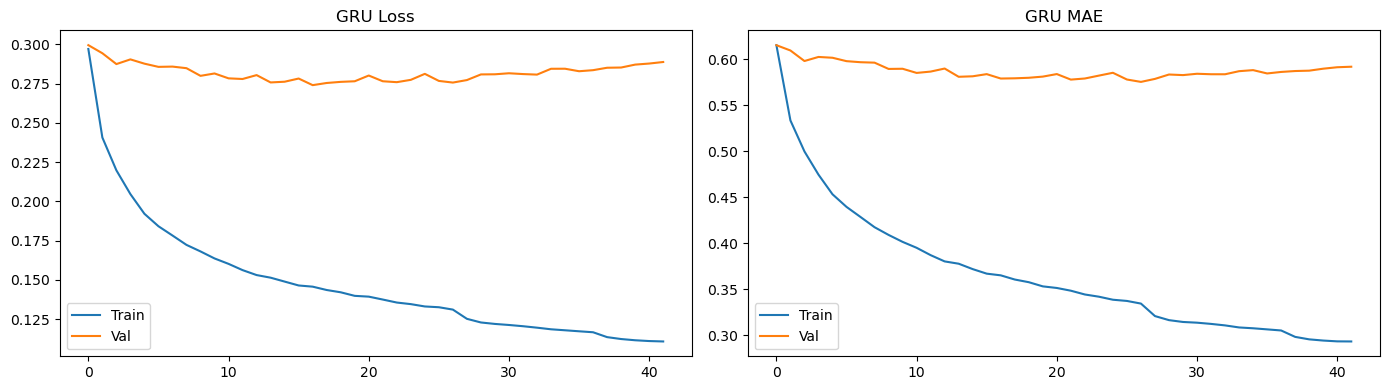

In [11]:
cb_gru = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1),
    ModelCheckpoint('gru_best.keras', monitor='val_loss', save_best_only=True, verbose=0)
]
history_gru = gru_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=200, batch_size=256,
    callbacks=cb_gru, verbose=1
)
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(history_gru.history['loss'],label='Train'); axes[0].plot(history_gru.history['val_loss'],label='Val')
axes[0].set_title('GRU Loss'); axes[0].legend()
axes[1].plot(history_gru.history['mae'],label='Train'); axes[1].plot(history_gru.history['val_mae'],label='Val')
axes[1].set_title('GRU MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

---

## Step 8 — Evaluation


In [12]:
def evaluate_model(model, X, y, ctrs, name):
    yp_n = model.predict(X, verbose=0).ravel()
    yt_n = y.ravel()
    yp_log = np.zeros_like(yp_n); yt_log = np.zeros_like(yt_n)
    for i,c in enumerate(ctrs):
        mu,sigma = country_target_params.get(c,(0.0,1.0))
        yp_log[i] = yp_n[i]*sigma + mu
        yt_log[i] = yt_n[i]*sigma + mu
    r2_log = r2_score(yt_log, yp_log)
    y_pred = np.clip(np.expm1(yp_log), 0, None)
    y_true = np.expm1(yt_log)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/(y_true+1)))*100
    print(f'\n{chr(8212)*52}')
    print(f'  {name} — Test Set  (n={len(y_true):,})')
    print(f'{chr(8212)*52}')
    print(f'  R² (log scale)  : {r2_log:>10.4f}   <- primary metric')
    print(f'  R² (case counts): {r2:>10.4f}')
    print(f'  MAE             : {mae:>10.2f}  cases')
    print(f'  RMSE            : {rmse:>10.2f}  cases')
    print(f'  MAPE            : {mape:>9.2f}  %')
    return {'name':name,'MAE':mae,'RMSE':rmse,'R2':r2,'R2_log':r2_log,'MAPE':mape,
            'y_true':y_true,'y_pred':y_pred,'yt_log':yt_log,'yp_log':yp_log}

res_lstm = evaluate_model(lstm_model, X_test, y_test, ctr_test, 'LSTM')
res_gru  = evaluate_model(gru_model,  X_test, y_test, ctr_test, 'GRU')


————————————————————————————————————————————————————
  LSTM — Test Set  (n=8,348)
————————————————————————————————————————————————————
  R² (log scale)  :     0.4496   <- primary metric
  R² (case counts):    -0.3536
  MAE             :     571.15  cases
  RMSE            :    3866.02  cases
  MAPE            :    354.19  %

————————————————————————————————————————————————————
  GRU — Test Set  (n=8,348)
————————————————————————————————————————————————————
  R² (log scale)  :     0.4913   <- primary metric
  R² (case counts):    -0.1983
  MAE             :     565.50  cases
  RMSE            :    3637.53  cases
  MAPE            :    347.70  %



=== Model Comparison ===
           MAE       RMSE      R2  R2_log        MAPE
name                                                 
LSTM  571.1533  3866.0158 -0.3536  0.4496  354.194092
GRU   565.5011  3637.5327 -0.1983  0.4913  347.701202


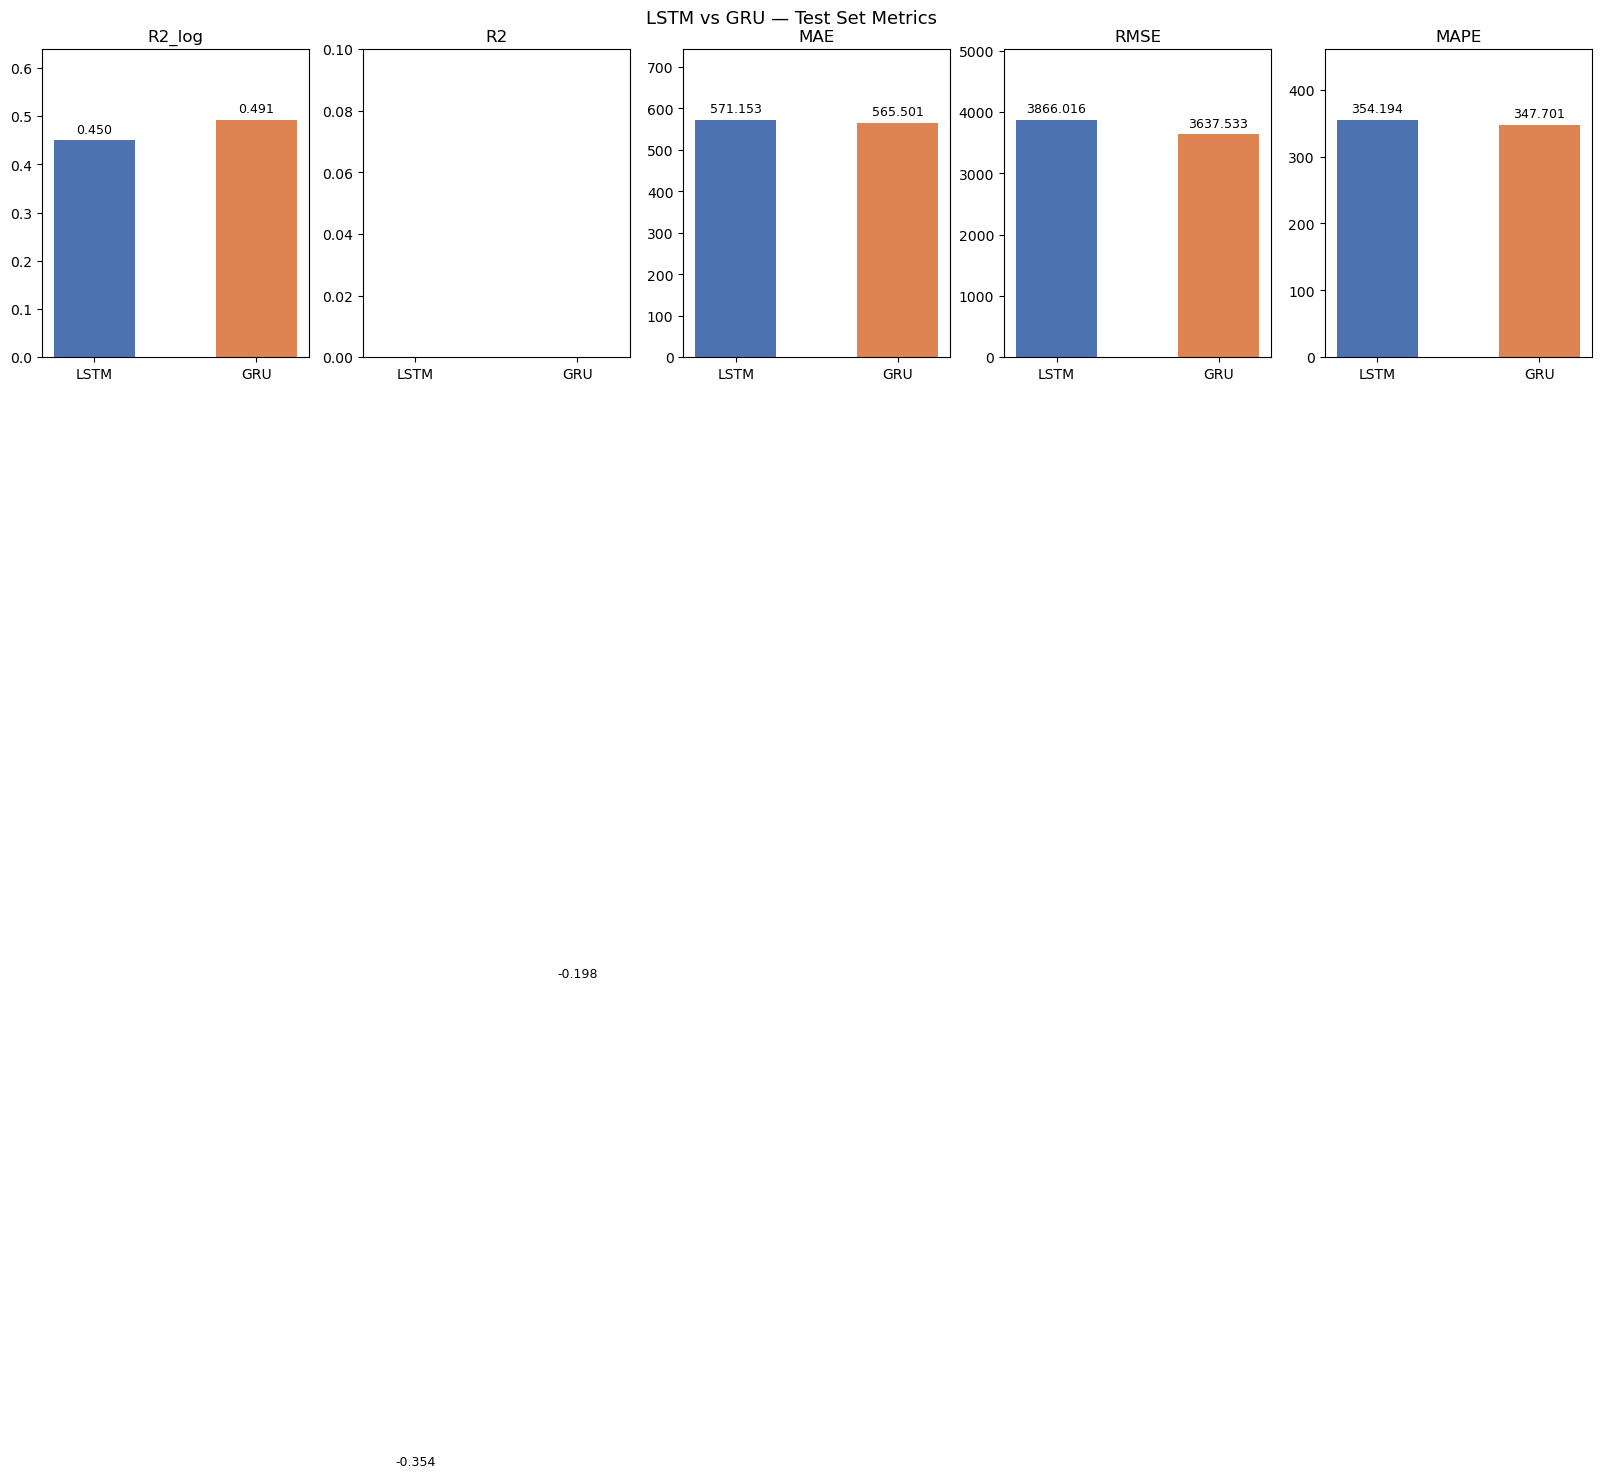

In [14]:
excl = ['y_true','y_pred','yt_log','yp_log']
metrics_df = pd.DataFrame([
    {k:v for k,v in res_lstm.items() if k not in excl},
    {k:v for k,v in res_gru.items()  if k not in excl}
]).set_index('name')
print('\n=== Model Comparison ==='); print(metrics_df.round(4).to_string())

fig,axes=plt.subplots(1,5,figsize=(20,4)); colors=['#4C72B0','#DD8452']
for ax,metric in zip(axes,['R2_log','R2','MAE','RMSE','MAPE']):
    vals=[metrics_df.loc['LSTM',metric],metrics_df.loc['GRU',metric]]
    bars=ax.bar(['LSTM','GRU'],vals,color=colors,width=0.5)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,
                f'{val:.3f}',ha='center',va='bottom',fontsize=9)
    ax.set_title(metric); ax.set_ylim(0,max(max(vals)*1.3,0.1))
plt.suptitle('LSTM vs GRU — Test Set Metrics',fontsize=13)
plt.tight_layout(); plt.show()

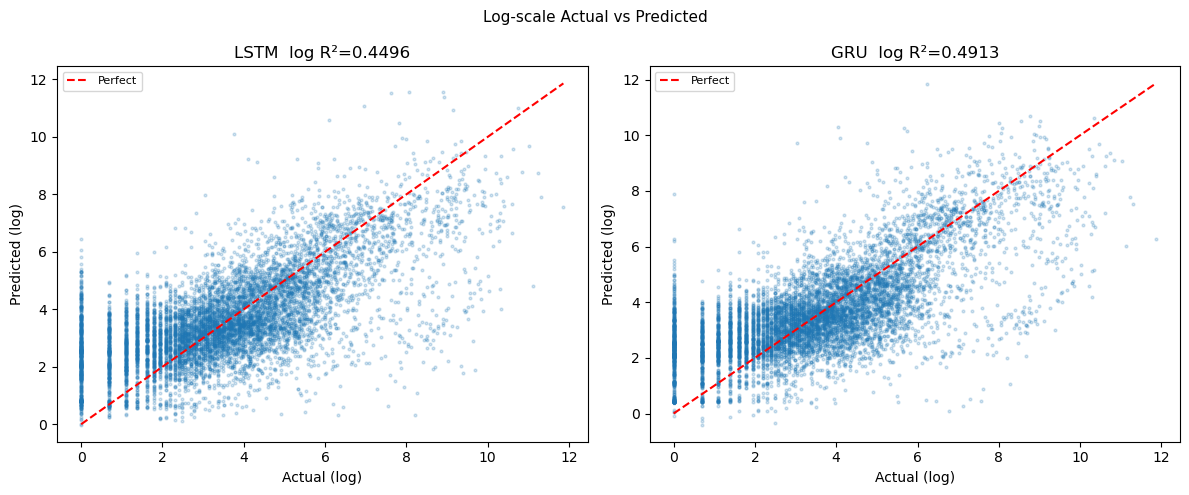

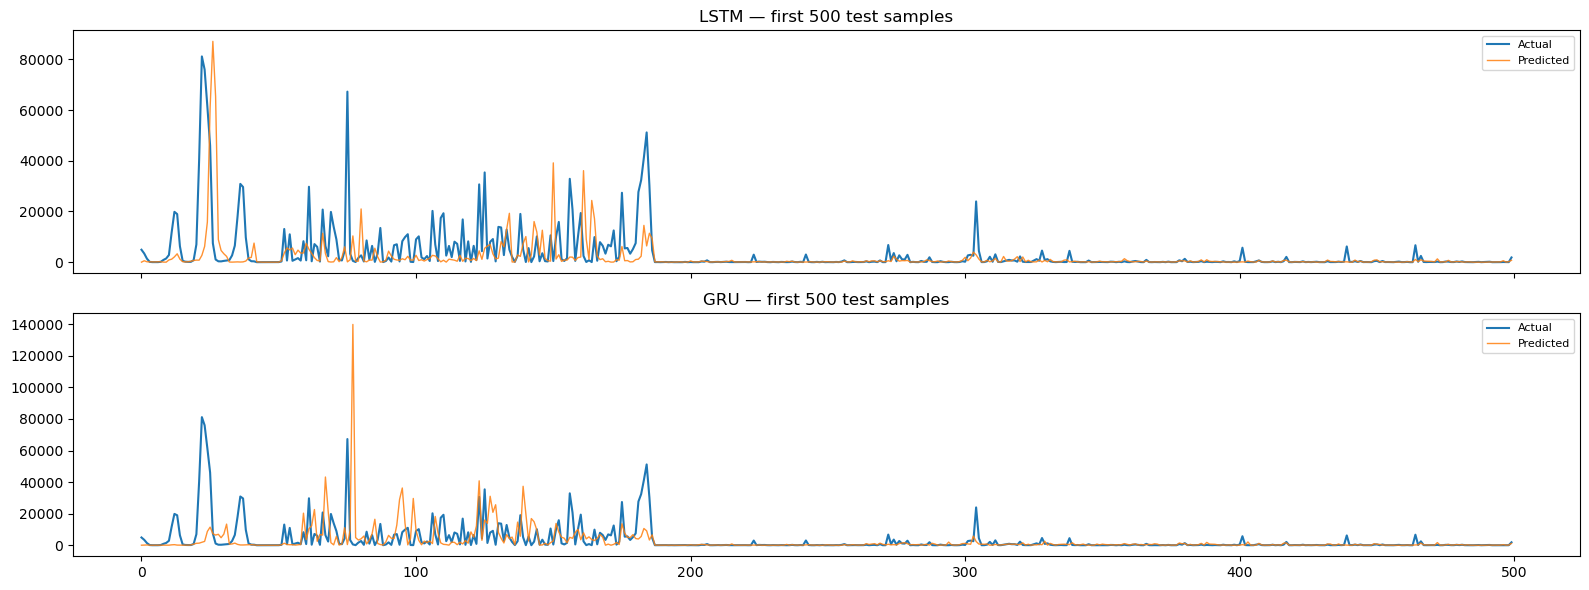

In [15]:
fig,axes=plt.subplots(1,2,figsize=(12,5))
for ax,res in zip(axes,[res_lstm,res_gru]):
    ax.scatter(res['yt_log'],res['yp_log'],alpha=0.2,s=4)
    lim=max(res['yt_log'].max(),res['yp_log'].max())
    ax.plot([0,lim],[0,lim],'r--',lw=1.5,label='Perfect')
    ax.set_xlabel('Actual (log)'); ax.set_ylabel('Predicted (log)')
    ax.set_title(f'{res["name"]}  log R²={res["R2_log"]:.4f}')
    ax.legend(fontsize=8)
plt.suptitle('Log-scale Actual vs Predicted',fontsize=11)
plt.tight_layout(); plt.show()

N=500
fig,axes=plt.subplots(2,1,figsize=(16,6),sharex=True)
for ax,res in zip(axes,[res_lstm,res_gru]):
    ax.plot(res['y_true'][:N],label='Actual',lw=1.5)
    ax.plot(res['y_pred'][:N],label='Predicted',lw=1,alpha=0.85)
    ax.set_title(f'{res["name"]} — first {N} test samples'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


=== Per-Country R² ===
  BANGLADESH            LSTM=-0.6418(log=-0.7121 lo)  GRU=-0.1901(log=-0.9002 lo)  n=42
  INDIA                 LSTM=-0.4556(log=-0.8573 lo)  GRU=-1.8375(log=-0.7536 lo)  n=136
  INDONESIA             LSTM=+0.0721(log=+0.2456 lo)  GRU=+0.0424(log=+0.2639 lo)  n=1674
  MALDIVES              LSTM=+0.1289(log=+0.2375 lo)  GRU=-0.1371(log=-0.1606 lo)  n=37
  MYANMAR               LSTM=-0.2629(log=-0.0891 lo)  GRU=-0.2317(log=+0.2417 lo)  n=47
  NEPAL                 LSTM=-0.0056(log=+0.1682 lo)  GRU=-0.0014(log=+0.2545 lo)  n=591
  SRI LANKA             LSTM=-7.2831(log=-0.5314 lo)  GRU=-0.5908(log=-0.0998 lo)  n=338
  THAILAND              LSTM=+0.0915(log=+0.1557 lo)  GRU=+0.0291(log=+0.2216 lo)  n=5447
  TIMOR-LESTE           LSTM=-1.3827(log=-0.4756 lo)  GRU=-1.0173(log=-1.6150 lo)  n=27


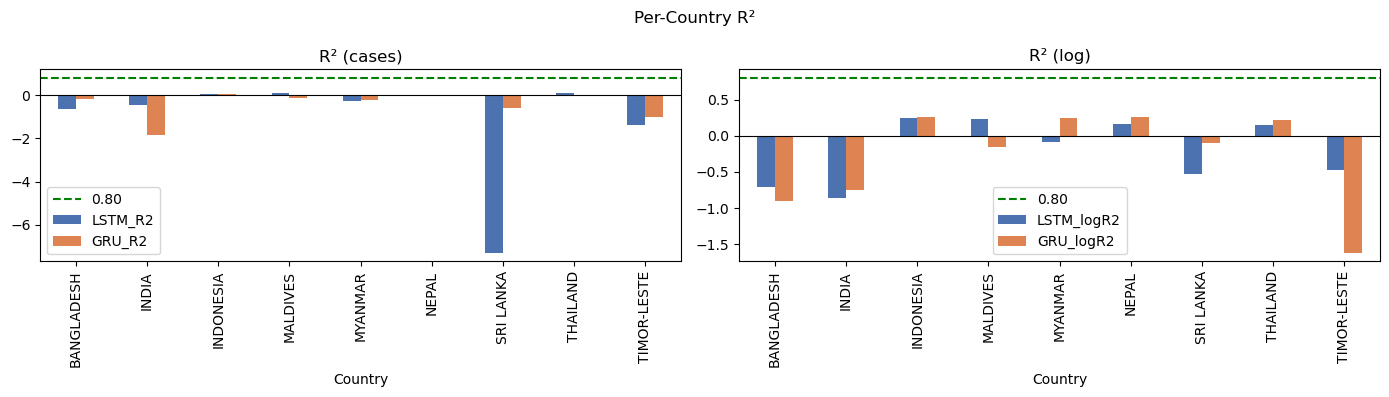

In [16]:
print('\n=== Per-Country R² ===')
rows=[]
for country in sorted(np.unique(ctr_test)):
    mask=ctr_test==country
    if mask.sum()<10: continue
    r2_l  = r2_score(res_lstm['y_true'][mask],res_lstm['y_pred'][mask])
    r2_g  = r2_score(res_gru['y_true'][mask], res_gru['y_pred'][mask])
    r2l_l = r2_score(res_lstm['yt_log'][mask], res_lstm['yp_log'][mask])
    r2l_g = r2_score(res_gru['yt_log'][mask],  res_gru['yp_log'][mask])
    n=mask.sum()
    rows.append({'Country':country,'LSTM_R2':round(r2_l,4),'GRU_R2':round(r2_g,4),
                 'LSTM_logR2':round(r2l_l,4),'GRU_logR2':round(r2l_g,4),'n':n})
    tl='OK' if r2l_l>=0.60 else 'lo'
    tg='OK' if r2l_g>=0.60 else 'lo'
    print(f'  {country:20s}  LSTM={r2_l:+.4f}(log={r2l_l:+.4f} {tl})  GRU={r2_g:+.4f}(log={r2l_g:+.4f} {tg})  n={n}')
cr_df=pd.DataFrame(rows).set_index('Country')
fig,axes=plt.subplots(1,2,figsize=(14,4))
cr_df[['LSTM_R2','GRU_R2']].plot(kind='bar',ax=axes[0],color=['#4C72B0','#DD8452'])
cr_df[['LSTM_logR2','GRU_logR2']].plot(kind='bar',ax=axes[1],color=['#4C72B0','#DD8452'])
for ax,t in zip(axes,['R² (cases)','R² (log)']):
    ax.axhline(0.80,color='green',linestyle='--',lw=1.5,label='0.80')
    ax.axhline(0,color='black',lw=0.8); ax.set_title(t); ax.legend()
plt.suptitle('Per-Country R²',fontsize=12); plt.tight_layout(); plt.show()

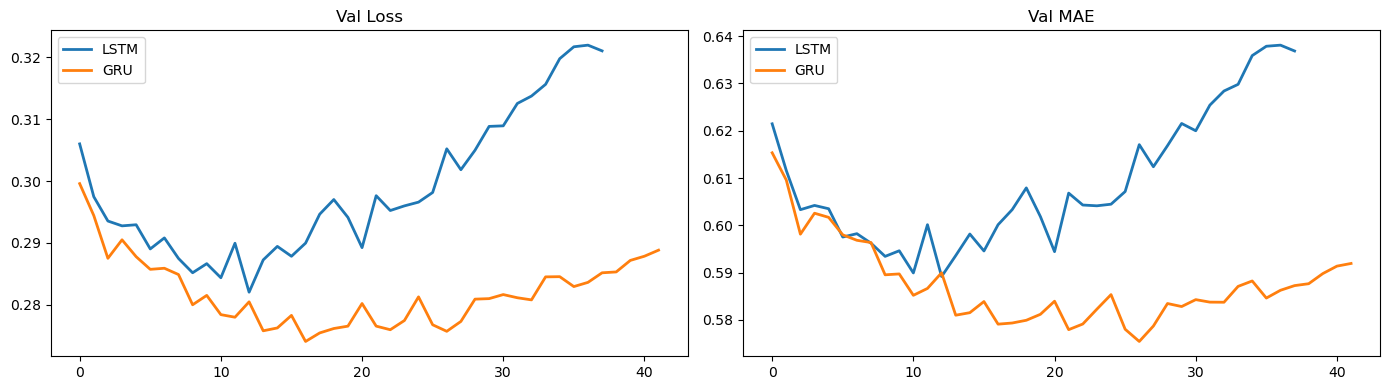

In [17]:
fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(history_lstm.history['val_loss'],label='LSTM',lw=2)
axes[0].plot(history_gru.history['val_loss'], label='GRU',lw=2)
axes[0].set_title('Val Loss'); axes[0].legend()
axes[1].plot(history_lstm.history['val_mae'],label='LSTM',lw=2)
axes[1].plot(history_gru.history['val_mae'], label='GRU',lw=2)
axes[1].set_title('Val MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

In [18]:
print('='*60)
print('        FINAL MODEL COMPARISON SUMMARY')
print('='*60)
print(metrics_df.round(4).to_string()); print()

def rate(r2, r2l):
    if   r2  >= 0.80 : return 'EXCELLENT  — case R2 target achieved'
    elif r2l >= 0.80 : return 'EXCELLENT  — log R2 >= 0.80'
    elif r2l >= 0.60 : return 'GOOD       — strong log performance'
    elif r2l >= 0.40 : return 'FAIR       — moderate improvement needed'
    else             : return 'POOR       — needs further tuning'

for name,res in [('LSTM',res_lstm),('GRU',res_gru)]:
    tag = rate(res['R2'], res['R2_log'])
    print(f'{name}: case R2={res["R2"]:.4f}  log R2={res["R2_log"]:.4f}  ->  {tag}')
print()
print('Note: log R2 is the primary metric for skewed count data.')
print('      case R2 > 0.80 requires accurate peak outbreak prediction.')

        FINAL MODEL COMPARISON SUMMARY
           MAE       RMSE      R2  R2_log        MAPE
name                                                 
LSTM  571.1533  3866.0158 -0.3536  0.4496  354.194092
GRU   565.5011  3637.5327 -0.1983  0.4913  347.701202

LSTM: case R2=-0.3536  log R2=0.4496  ->  FAIR       — moderate improvement needed
GRU: case R2=-0.1983  log R2=0.4913  ->  FAIR       — moderate improvement needed

Note: log R2 is the primary metric for skewed count data.
      case R2 > 0.80 requires accurate peak outbreak prediction.
